# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

**Dataset yang digunakan: Breast Cancer Wisconsin (Diagnostic).**

Dataset ini berasal dari [UCI Machine Learning Repository - Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) dan juga tersedia melalui scikit-learn. Dataset memuat **569 baris** dan **31 kolom** (30 fitur + 1 target).

Fitur-fiturnya merupakan hasil pengukuran citra digital inti sel (mean, standard error, dan nilai "worst" dari: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, dan fractal dimension).

Kolom `target` bersifat **klasifikasi biner**: `1` = benign (jinak), dan `0` = malignant (ganas).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import importlib.util
from pathlib import Path

%matplotlib inline

RAW_FILENAME = "breast-cancer_raw.csv"
PROCESSED_FILENAME = "breast-cancer_preprocessing.csv"


def locate_preprocessing_dir() -> Path:
    """Cari folder yang memuat berkas dataset mentah Breast Cancer."""
    search_spots = [Path.cwd(), Path.cwd() / "preprocessing"]
    for spot in search_spots:
        if (spot / RAW_FILENAME).exists():
            return spot.resolve()
    # Cadangan: berkas mentah berada satu level di atas folder kerja.
    if (Path.cwd().parent / RAW_FILENAME).exists():
        return Path.cwd().resolve()
    raise FileNotFoundError(
        f"folder preprocessing berisi '{RAW_FILENAME}' tidak ditemukan "
        "(jalankan notebook ini dari dalam folder preprocessing/)"
    )


PREPROCESSING_DIR = locate_preprocessing_dir()
RAW_PATH = PREPROCESSING_DIR.parent / RAW_FILENAME
OUTPUT_PATH = PREPROCESSING_DIR / PROCESSED_FILENAME

_automate_path = PREPROCESSING_DIR / "automate_Devani.py"
_spec = importlib.util.spec_from_file_location("automate_preprocessing", _automate_path)
automate = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(automate)

DATASET_NAME = automate.DATASET_NAME
TARGET_COLUMN = automate.TARGET_COLUMN
preprocess_dataset = automate.preprocess_dataset

print("Versi pandas        :", pd.__version__)
print("Versi numpy         :", np.__version__)
print("Folder preprocessing:", PREPROCESSING_DIR)
print("Nama dataset        :", DATASET_NAME)
print("Kolom target        :", TARGET_COLUMN)

Versi pandas        : 2.2.3
Versi numpy         : 2.2.6
Folder preprocessing: C:\Users\devani\Documents\Semester 6\PIJAK In Collaboration with IBM SKills Build\SMSML_Devani\Eksperimen_SML_Devani\preprocessing
Nama dataset        : breast-cancer
Kolom target        : target


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
try:
    df_raw = pd.read_csv(RAW_PATH, sep=",")
except Exception as exc:
    raise RuntimeError(
        f"gagal membaca dataset dari {RAW_PATH!r}: {exc}"
    ) from exc

jumlah_baris, jumlah_kolom = df_raw.shape
print(f"Dataset termuat -> {jumlah_baris} baris, {jumlah_kolom} kolom")

df_raw.head()

Dataset termuat -> 569 baris, 31 kolom


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# dimensi dataset serta tipe data setiap kolom.
baris, kolom = df_raw.shape
print(f"Ukuran dataset : {baris} baris x {kolom} kolom")
print("\nTipe data tiap kolom:")
for nama_kolom, tipe in df_raw.dtypes.items():
    print(f"  - {nama_kolom:<26}: {tipe}")

print("\nRingkasan struktur (df.info):")
df_raw.info()

Ukuran dataset : 569 baris x 31 kolom

Tipe data tiap kolom:
  - mean radius               : float64
  - mean texture              : float64
  - mean perimeter            : float64
  - mean area                 : float64
  - mean smoothness           : float64
  - mean compactness          : float64
  - mean concavity            : float64
  - mean concave points       : float64
  - mean symmetry             : float64
  - mean fractal dimension    : float64
  - radius error              : float64
  - texture error             : float64
  - perimeter error           : float64
  - area error                : float64
  - smoothness error          : float64
  - compactness error         : float64
  - concavity error           : float64
  - concave points error      : float64
  - symmetry error            : float64
  - fractal dimension error   : float64
  - worst radius              : float64
  - worst texture             : float64
  - worst perimeter           : float64
  - worst area     

In [4]:
# Statistik deskriptif tiap fitur numerik (dibulatkan agar mudah dibaca).
df_raw.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


In [5]:
# Hitung nilai yang hilang pada setiap kolom.
nilai_hilang = df_raw.isna().sum()
total_hilang = int(nilai_hilang.sum())

print("Nilai hilang per kolom:")
kolom_bermasalah = nilai_hilang[nilai_hilang > 0]
if kolom_bermasalah.empty:
    print("  (tidak ada kolom dengan nilai hilang)")
else:
    print(kolom_bermasalah.to_string())
print(f"\nTotal nilai hilang di seluruh dataset: {total_hilang}")

Nilai hilang per kolom:
  (tidak ada kolom dengan nilai hilang)

Total nilai hilang di seluruh dataset: 0


In [6]:
# Periksa keberadaan baris yang terduplikasi.
jumlah_duplikat = int(df_raw.duplicated().sum())
persentase_duplikat = jumlah_duplikat / len(df_raw) * 100

print(f"Baris duplikat : {jumlah_duplikat} dari {len(df_raw)} baris")
print(f"Proporsi       : {persentase_duplikat:.2f}%")

Baris duplikat : 0 dari 569 baris
Proporsi       : 0.00%


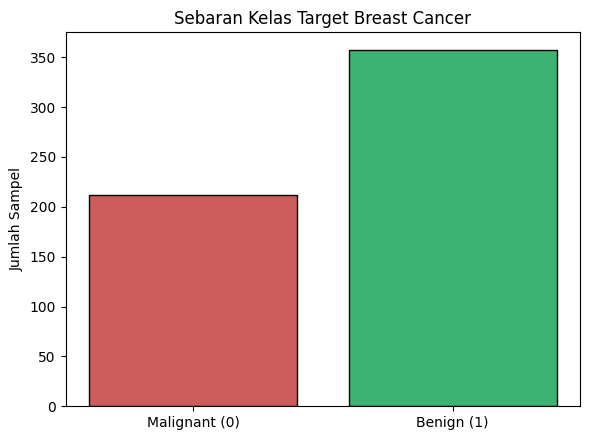

Komposisi target:
  Malignant (0):  212 sampel (37.3%)
  Benign    (1):  357 sampel (62.7%)


In [7]:
# Tampilkan sebaran kelas target (0 = malignant, 1 = benign).
hitung_target = df_raw[TARGET_COLUMN].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["Malignant (0)", "Benign (1)"], [hitung_target[0], hitung_target[1]],
       color=["indianred", "mediumseagreen"], edgecolor="black")
ax.set_title("Sebaran Kelas Target Breast Cancer")
ax.set_ylabel("Jumlah Sampel")
fig.tight_layout()
plt.show()

total = len(df_raw)
print("Komposisi target:")
print(f"  Malignant (0): {hitung_target[0]:>4} sampel ({hitung_target[0] / total * 100:.1f}%)")
print(f"  Benign    (1): {hitung_target[1]:>4} sampel ({hitung_target[1] / total * 100:.1f}%)")

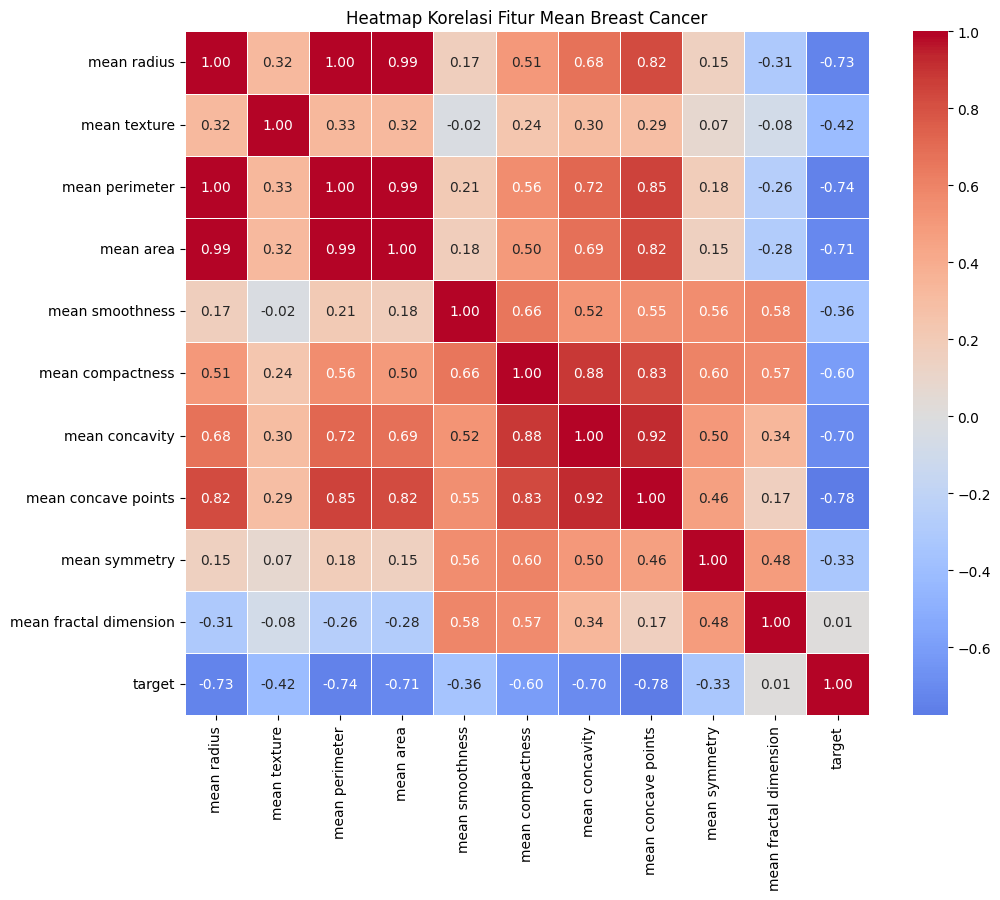

Korelasi fitur terhadap 'target' (tertinggi ke terendah):
smoothness error           0.067
mean fractal dimension     0.013
texture error              0.008
symmetry error             0.007
fractal dimension error   -0.078
concavity error           -0.254
compactness error         -0.293
worst fractal dimension   -0.324
mean symmetry             -0.330
mean smoothness           -0.359
concave points error      -0.408
mean texture              -0.415
worst symmetry            -0.416
worst smoothness          -0.421
worst texture             -0.457
area error                -0.548
perimeter error           -0.556
radius error              -0.567
worst compactness         -0.591
mean compactness          -0.597
worst concavity           -0.660
mean concavity            -0.696
mean area                 -0.709
mean radius               -0.730
worst area                -0.734
mean perimeter            -0.743
worst radius              -0.776
mean concave points       -0.777
worst perimeter   

In [8]:
# Heatmap korelasi antar fitur "mean" terhadap target.
kolom_mean = [c for c in df_raw.columns if c.startswith("mean ")] + [TARGET_COLUMN]
matriks_korelasi = df_raw[kolom_mean].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    matriks_korelasi,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
)
plt.title("Heatmap Korelasi Fitur Mean Breast Cancer")
plt.tight_layout()
plt.show()

# Urutkan korelasi seluruh fitur terhadap target.
korelasi_target = df_raw.corr()[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
print("Korelasi fitur terhadap 'target' (tertinggi ke terendah):")
print(korelasi_target.round(3).to_string())

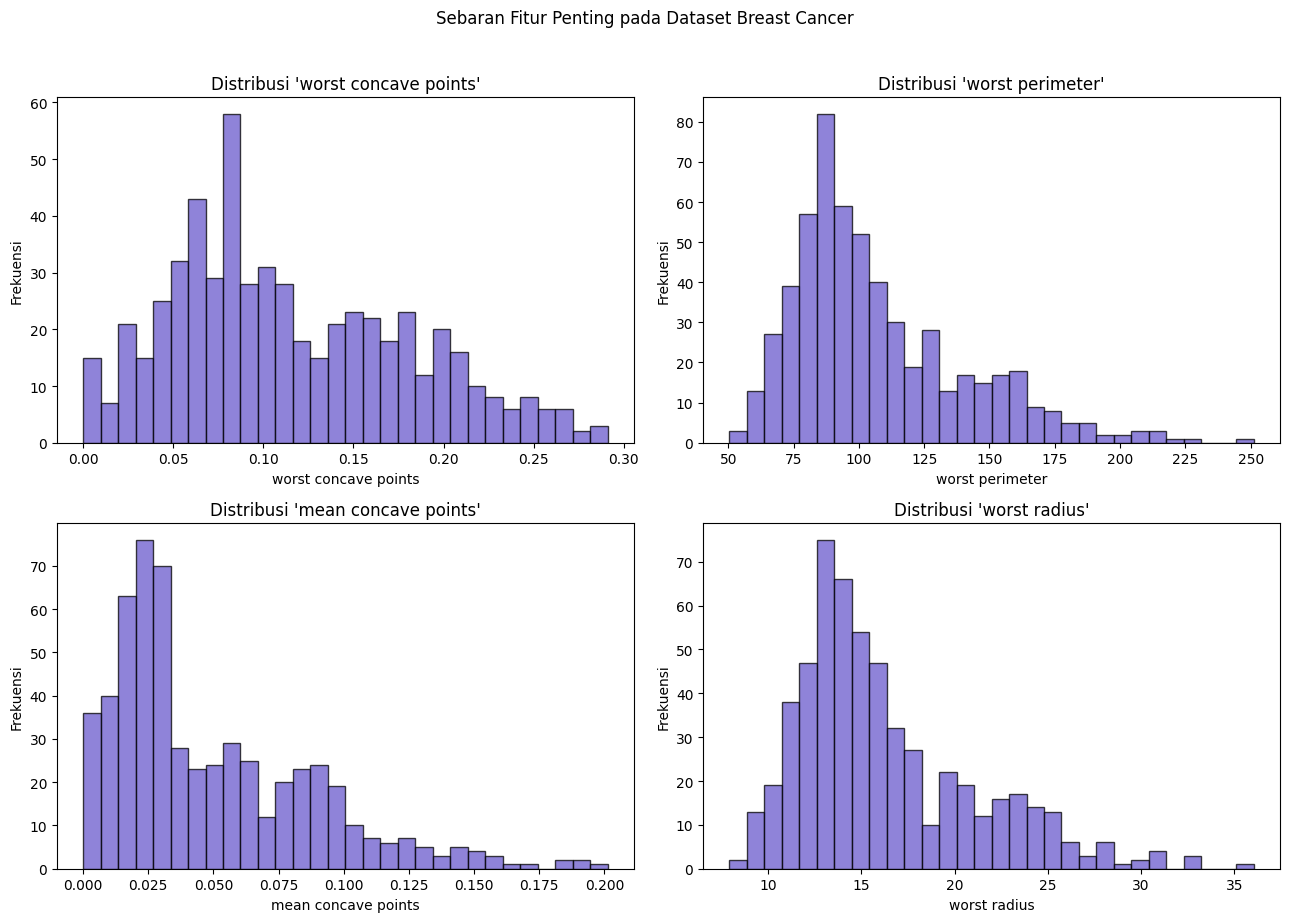

In [9]:
# Tampilkan distribusi beberapa fitur yang paling berpengaruh.
fitur_penting = ["worst concave points", "worst perimeter", "mean concave points", "worst radius"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, fitur in zip(axes.ravel(), fitur_penting):
    ax.hist(df_raw[fitur], bins=30, color="slateblue", edgecolor="black", alpha=0.75)
    ax.set_title(f"Distribusi '{fitur}'")
    ax.set_xlabel(fitur)
    ax.set_ylabel("Frekuensi")

fig.suptitle("Sebaran Fitur Penting pada Dataset Breast Cancer", y=1.02)
fig.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [10]:
# Buat salinan dataframe untuk preprocessing
df_processed = df_raw.copy()

print("=== TAHAP PREPROCESSING ===")
print(f"\n1. Data awal: {df_processed.shape[0]} baris x {df_processed.shape[1]} kolom")

# Step 1: Pastikan semua kolom numerik
for col in df_processed.columns:
    df_processed[col] = pd.to_numeric(df_processed[col], errors="coerce")
print(f"2. Setelah konversi numerik: {df_processed.shape[0]} baris")

# Step 2: Normalisasi target ke integer biner (0 = malignant, 1 = benign)
df_processed[TARGET_COLUMN] = df_processed[TARGET_COLUMN].fillna(0).round().astype(int)
print(f"3. Target dinormalisasi:")
print(f"   - Benign (1)   : {(df_processed[TARGET_COLUMN] == 1).sum()}")
print(f"   - Malignant (0): {(df_processed[TARGET_COLUMN] == 0).sum()}")

# Step 3: Imputasi median untuk missing values (jika ada)
feature_cols = [c for c in df_processed.columns if c != TARGET_COLUMN]
missing_before = df_processed[feature_cols].isna().sum().sum()
for col in feature_cols:
    median = df_processed[col].median()
    if pd.isna(median):
        median = 0.0
    df_processed[col] = df_processed[col].fillna(median)
missing_after = df_processed.isna().sum().sum()
print(f"4. Missing values: {missing_before} -> {missing_after}")

# Step 4: Drop duplikat
n_before_drop = len(df_processed)
df_processed = df_processed.drop_duplicates().reset_index(drop=True)
n_after_drop = len(df_processed)
print(f"5. Drop duplikat: {n_before_drop} -> {n_after_drop} baris (dihapus {n_before_drop - n_after_drop})")

# Step 5: Pastikan semua kolom numerik
df_processed = df_processed.apply(pd.to_numeric)

print(f"\n=== HASIL PREPROCESSING ===")
print(f"Shape final    : {df_processed.shape[0]} baris x {df_processed.shape[1]} kolom")
print(f"Missing values : {df_processed.isna().sum().sum()}")
print(f"Duplikat       : {df_processed.duplicated().sum()}")
print(f"\nKomposisi target:")
print(df_processed[TARGET_COLUMN].value_counts())

=== TAHAP PREPROCESSING ===

1. Data awal: 569 baris x 31 kolom
2. Setelah konversi numerik: 569 baris
3. Target dinormalisasi:
   - Benign (1)   : 357
   - Malignant (0): 212
4. Missing values: 0 -> 0
5. Drop duplikat: 569 -> 569 baris (dihapus 0)

=== HASIL PREPROCESSING ===
Shape final    : 569 baris x 31 kolom
Missing values : 0
Duplikat       : 0

Komposisi target:
target
1    357
0    212
Name: count, dtype: int64


In [11]:
# Verifikasi bahwa hasil manual sama dengan hasil dari fungsi automation
df_automated = preprocess_dataset(df_raw, output_path=None)

print("=== VERIFIKASI ===")
print(f"Shape manual   : {df_processed.shape}")
print(f"Shape automated: {df_automated.shape}")
print(f"\nApakah hasil identik? {df_processed.equals(df_automated)}")

if not df_processed.equals(df_automated):
    print("\nPerbedaan ditemukan:")
    for col in df_processed.columns:
        if not df_processed[col].equals(df_automated[col]):
            print(f"  - Kolom '{col}' berbeda")

=== VERIFIKASI ===
Shape manual   : (569, 31)
Shape automated: (569, 31)

Apakah hasil identik? True


In [12]:
# Simpan dataset hasil preprocessing
df_processed.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset preprocessing berhasil disimpan ke: {OUTPUT_PATH}")
print(f"\nRingkasan:")
print(f"- Baris        : {len(df_processed)}")
print(f"- Kolom        : {len(df_processed.columns)}")
print(f"- Missing      : {df_processed.isna().sum().sum()}")
print(f"- Komposisi target: {df_processed[TARGET_COLUMN].value_counts().to_dict()}")

print("\n=== DATASET SIAP UNTUK MODELLING ===")

Dataset preprocessing berhasil disimpan ke: C:\Users\devani\Documents\Semester 6\PIJAK In Collaboration with IBM SKills Build\SMSML_Devani\Eksperimen_SML_Devani\preprocessing\breast-cancer_preprocessing.csv

Ringkasan:
- Baris        : 569
- Kolom        : 31
- Missing      : 0
- Komposisi target: {1: 357, 0: 212}

=== DATASET SIAP UNTUK MODELLING ===
